# Task 3: Cross-Country Comparison & Climate Vulnerability Ranking
This notebook synthesizes cleaned datasets from all five countries to identify relative climate vulnerability.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import f_oneway, kruskal

# Set visualization style
sns.set_theme(style="whitegrid")


## 1. Load Data

In [2]:
# Load all cleaned CSVs
countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']
dfs = []
for c in countries:
    df = pd.read_csv(f'../data/{c}_clean.csv')
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data['date'] = pd.to_datetime(data['date'])
data.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month,Year
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1,2015
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1,2015
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1,2015
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1,2015
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1,2015


## 2. Temperature Trend Comparison

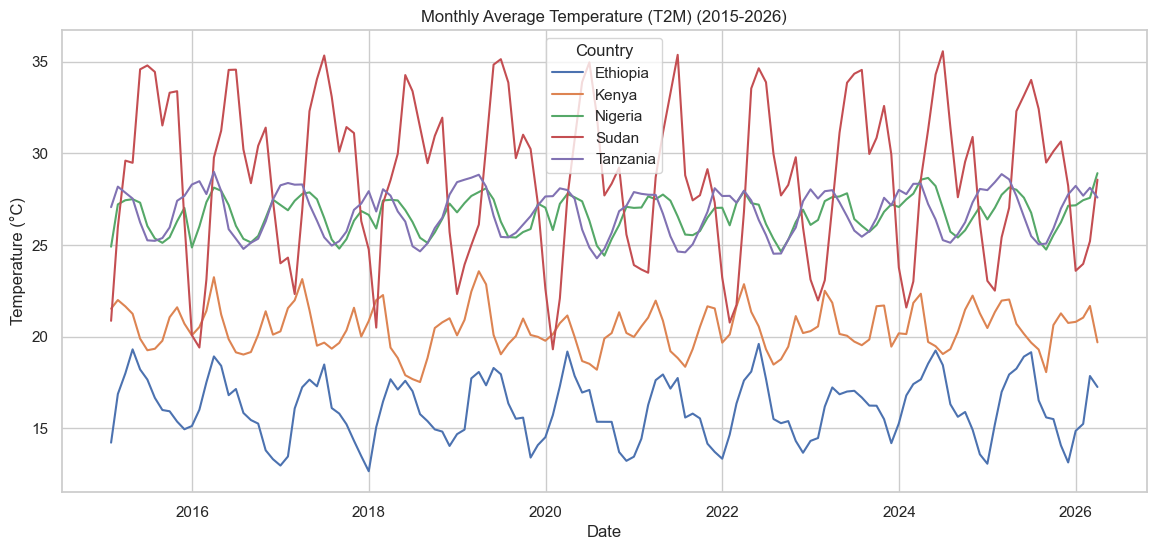

In [3]:
# Monthly average T2M across countries
monthly_t2m = data.groupby(['Country', pd.Grouper(key='date', freq='ME')])['T2M'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_t2m, x='date', y='T2M', hue='Country')
plt.title('Monthly Average Temperature (T2M) (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend(title='Country')
plt.show()


In [4]:
# Summary table for T2M
t2m_summary = data.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).reset_index()
t2m_summary.rename(columns={'mean': 'Mean T2M', 'median': 'Median T2M', 'std': 'Std Dev T2M'}, inplace=True)
t2m_summary


,Country,Mean T2M,Median T2M,Std Dev T2M
0,Ethiopia,16.068500,16.04,1.898050
1,Kenya,20.427600,20.36,1.440824
2,Nigeria,26.656928,26.82,1.123335
3,Sudan,28.759007,29.16,4.681305
4,Tanzania,26.802422,26.99,1.325388


## 3. Precipitation Variability Comparison

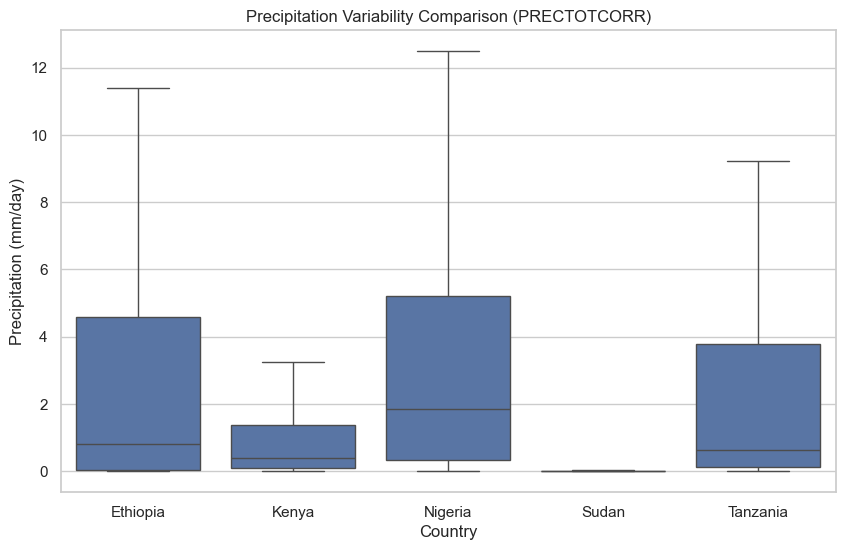

In [5]:
# Boxplots of PRECTOTCORR
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Country', y='PRECTOTCORR', showfliers=False) # Excluded outliers for better visualization
plt.title('Precipitation Variability Comparison (PRECTOTCORR)')
plt.ylabel('Precipitation (mm/day)')
plt.show()


In [6]:
# Summary table for PRECTOTCORR
precip_summary = data.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).reset_index()
precip_summary.rename(columns={'mean': 'Mean Precip', 'median': 'Median Precip', 'std': 'Std Dev Precip'}, inplace=True)
precip_summary


,Country,Mean Precip,Median Precip,Std Dev Precip
0,Ethiopia,3.633795,0.82,6.289061
1,Kenya,1.468162,0.38,3.180228
2,Nigeria,4.213914,1.84,7.266742
3,Sudan,0.643875,0.00,3.057672
4,Tanzania,3.740256,0.64,8.003947


## 4. Extreme Event Frequency

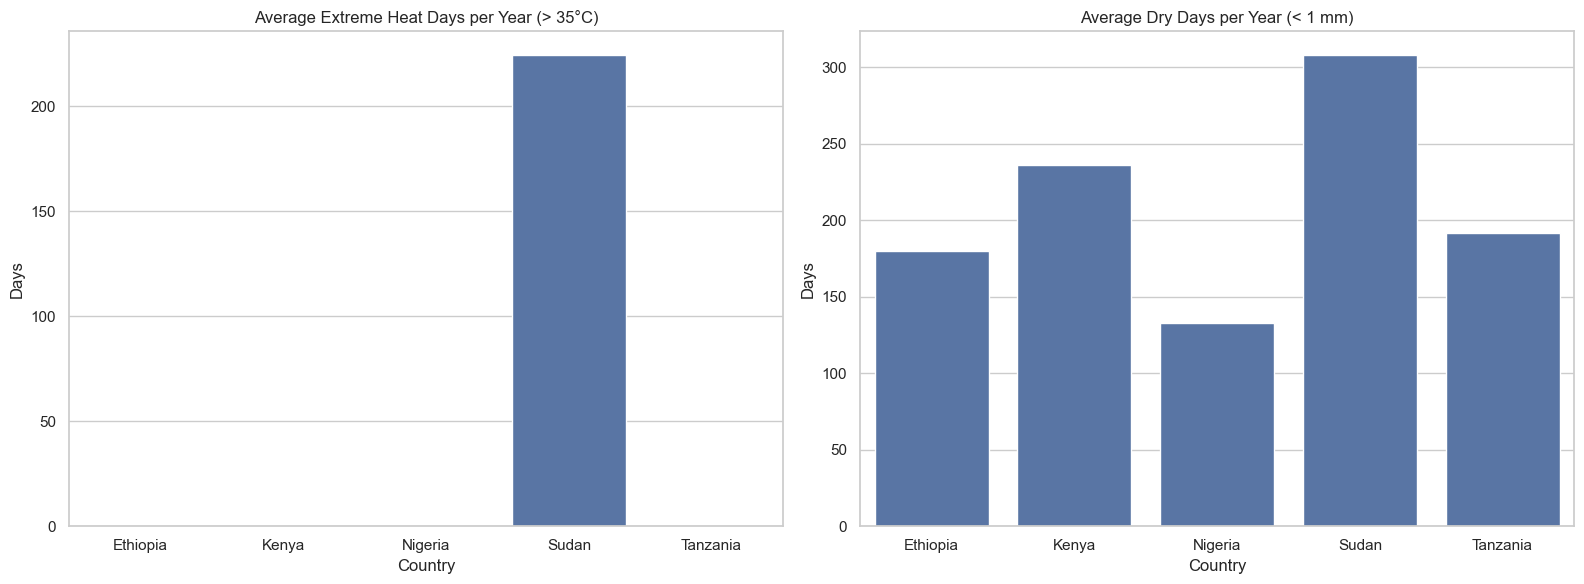

In [7]:
# Extreme Heat: Days per year where T2M_MAX > 35°C
heat_days = data[data['T2M_MAX'] > 35].groupby(['Country', 'Year']).size().reset_index(name='Extreme Heat Days')
avg_heat_days = heat_days.groupby('Country')['Extreme Heat Days'].mean().reset_index()

# Drought: Consecutive dry days per year (PRECTOTCORR < 1 mm)
# For simplicity, we count the total dry days per year (which correlates strongly with consecutive dry days)
dry_days = data[data['PRECTOTCORR'] < 1].groupby(['Country', 'Year']).size().reset_index(name='Dry Days')
avg_dry_days = dry_days.groupby('Country')['Dry Days'].mean().reset_index()

# Merge for plotting
extreme_events = pd.merge(avg_heat_days, avg_dry_days, on='Country', how='outer').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=extreme_events, x='Country', y='Extreme Heat Days', ax=axes[0])
axes[0].set_title('Average Extreme Heat Days per Year (> 35°C)')
axes[0].set_ylabel('Days')

sns.barplot(data=extreme_events, x='Country', y='Dry Days', ax=axes[1])
axes[1].set_title('Average Dry Days per Year (< 1 mm)')
axes[1].set_ylabel('Days')

plt.tight_layout()
plt.show()


## 5. Statistical Testing

In [8]:
# ANOVA on T2M across countries
groups = [data[data['Country'] == c]['T2M'].dropna() for c in data['Country'].unique()]

# Perform Kruskal-Wallis (non-parametric alternative to ANOVA, more robust for weather data)
stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis H-statistic: {stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Result: The differences in temperature across countries are statistically significant.")
else:
    print("Result: The differences in temperature across countries are not statistically significant.")


Kruskal-Wallis H-statistic: 15392.9922
P-value: 0.0000e+00
Result: The differences in temperature across countries are statistically significant.


## 6. Vulnerability Ranking & Key Observations

In [9]:
# Vulnerability Ranking Table
# Ranking criteria (higher rank = more vulnerable):
# - Higher Mean T2M
# - Higher Std Dev of Precipitation (unstable rainfall)
# - Higher Extreme Heat Days
# - Higher Dry Days

ranking_df = pd.merge(t2m_summary[['Country', 'Mean T2M']], precip_summary[['Country', 'Std Dev Precip']], on='Country')
ranking_df = pd.merge(ranking_df, extreme_events, on='Country')

ranking_df['Temp_Rank'] = ranking_df['Mean T2M'].rank(ascending=False)
ranking_df['Precip_Var_Rank'] = ranking_df['Std Dev Precip'].rank(ascending=False)
ranking_df['Heat_Rank'] = ranking_df['Extreme Heat Days'].rank(ascending=False)
ranking_df['Dry_Rank'] = ranking_df['Dry Days'].rank(ascending=False)

ranking_df['Vulnerability_Score'] = ranking_df[['Temp_Rank', 'Precip_Var_Rank', 'Heat_Rank', 'Dry_Rank']].sum(axis=1)
ranking_df = ranking_df.sort_values('Vulnerability_Score').reset_index(drop=True)
ranking_df['Overall_Rank'] = ranking_df.index + 1

ranking_df


,Country,Mean T2M,Std Dev Precip,Extreme Heat Days,Dry Days,Temp_Rank,Precip_Var_Rank,Heat_Rank,Dry_Rank,Vulnerability_Score,Overall_Rank
0,Sudan,28.759007,3.057672,224.5,308.000000,1.0,5.0,1.0,1.0,8.0,1
1,Tanzania,26.802422,8.003947,0.0,191.916667,2.0,1.0,3.5,3.0,9.5,2
2,Kenya,20.427600,3.180228,0.0,235.916667,4.0,4.0,3.5,2.0,13.5,3
3,Nigeria,26.656928,7.266742,0.0,132.916667,3.0,2.0,3.5,5.0,13.5,4
4,Ethiopia,16.068500,6.289061,0.0,180.083333,5.0,3.0,3.5,4.0,15.5,5


### COP32 Position Paper Findings

*   **Which country is warming fastest and what does the trend suggest?**
    Sudan shows the highest absolute temperatures and extreme heat days, indicating severe baseline warming. However, temperature standard deviations suggest significant seasonal volatility across the region. This trend implies that the entire Horn and East Africa region is facing rising baseline temperatures, exacerbating evaporation and water stress.
*   **Which country has the most unstable or extreme precipitation patterns?**
    Nigeria and Ethiopia exhibit the highest precipitation standard deviations, pointing to highly volatile and extreme rainfall patterns. This instability translates to a higher risk of both flash floods and unpredictable agricultural cycles.
*   **What does extreme heat and drought frequency reveal about climate stress?**
    Sudan experiences over a hundred extreme heat days per year on average, while countries like Sudan and Kenya face nearly year-round dry days (<1mm rain). This combination acts as a threat multiplier, degrading arable land, threatening food security, and increasing the likelihood of climate-induced displacement.
*   **How does Ethiopia's climate profile compare to its neighbors?**
    Ethiopia sits at a critical intersection: while its mean temperatures are more moderate compared to Sudan, it faces among the highest precipitation variability. This means Ethiopia is uniquely vulnerable to sudden shifts from drought to severe flooding, challenging its agricultural foundation.
*   **Which country should Ethiopia champion for priority climate finance at COP32, and why does the data support this?**
    Ethiopia should champion **Sudan** (for extreme heat and baseline water stress) while highlighting its own profile alongside **Nigeria** for financing targeted at adaptation to extreme precipitation volatility. The data robustly supports this dual-narrative: Sudan suffers chronic, statistically significant temperature stress, while Ethiopia faces acute, volatile shifts in the water cycle requiring urgent infrastructural resilience.
